In [1]:
import random as rd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
xmax = 0.20
ymax = 1.00

position = str(input("Position haute ou basse : "))

if position == 'basse' or position == 'Basse': 
    d = 0.41 
    
elif position == 'haute' or position =='Haute' :
    d= 1.17


In [3]:
## Simulation de la distance moyenne

def f(theta) : ## Fonction cos(theta)**2 
    return (np.cos(theta))**2

Ld = [] ## Liste des résultats pour la distance             
Lt = [] ## Liste des résultats pour théta 

N = 100000 ## Nombre d'évenements

for i in range(N) :
    x1 = rd.uniform(0, xmax)
    y1 = rd.uniform(0, ymax)
    phi = rd.uniform(0, 2*np.pi)
    theta = rd.uniform(-np.pi/2, np.pi/2)
    b = rd.uniform(0, 1)
    if f(theta) >= b: # Masque 
        Lt.append(theta)
        a = d*np.tan(theta)
        x2 = x1+a*np.sin(phi)
        y2 = y1 + a*np.cos(phi)
        if 0 < x2 < xmax and 0 < y2 < ymax :
            Ld.append(d*np.sqrt(1 + (np.tan(theta))**2))

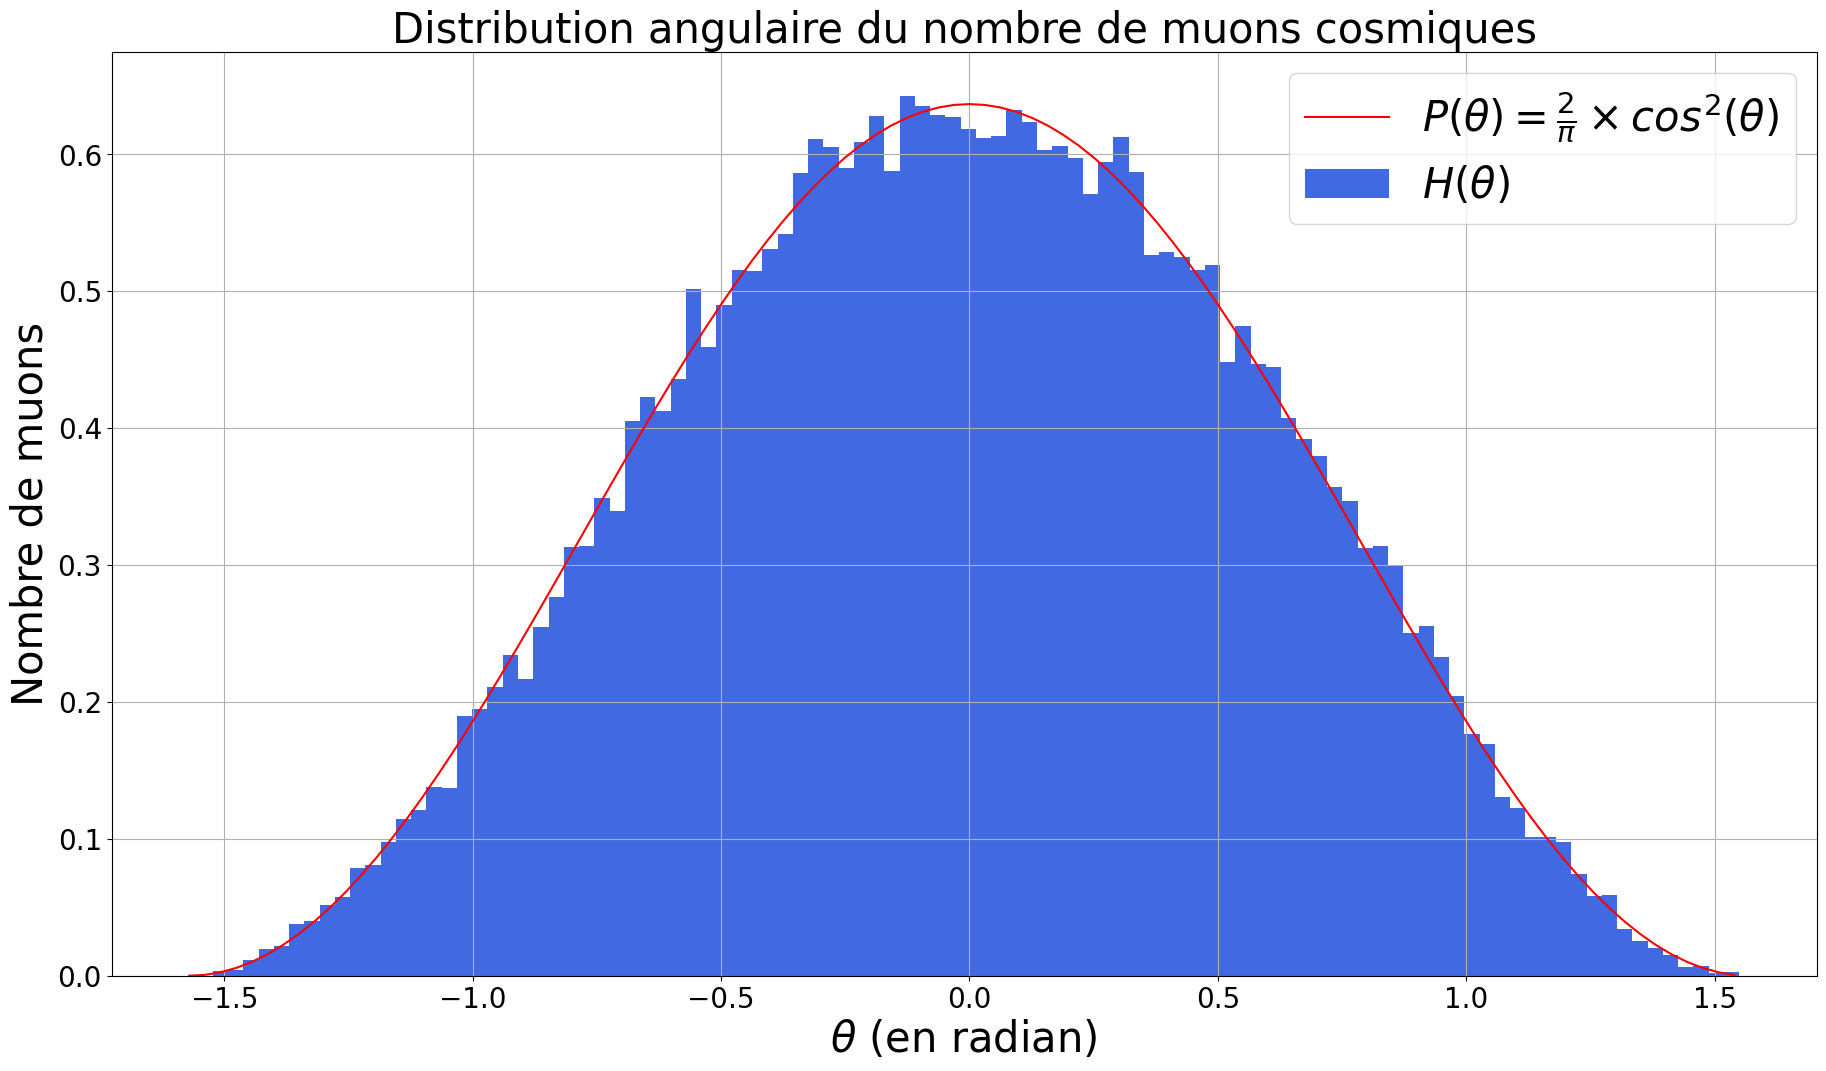

In [4]:
## Distribution pour théta

X = [-np.pi/2 + i*np.pi/100 for i in range(100)] ## Pour s'assurer que la loi est respectée
Y = [2/np.pi*(np.cos(k))**2 for k in X]

plt.figure(figsize = (22, 12))
plt.plot(X, Y, color = 'red', label = r'$P(\theta) = \frac{2}{\pi} \times cos^2(\theta)$')
plt.hist(Lt, bins = 100, density = 1, color = 'royalblue', label = r'$H(\theta)$')
plt.xlabel(r'$\theta$ (en radian)', fontsize=30)
plt.ylabel('Nombre de muons', fontsize=30)
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)
plt.title(r'Distribution angulaire du nombre de muons cosmiques', fontsize = 30)
plt.legend(loc = "best", fontsize = 30)
plt.grid()
plt.show()


Soit la fonction $f(x) = A\ cos^2(x)$. On sait que $I = \int_{-\pi / 2}^{\pi / 2} f(x) dx = 1$.

$\Rightarrow I = A \int_{-\pi / 2}^{\pi / 2} cos^2(x) dx = A \int_{-\pi / 2}^{\pi / 2} \frac{1 + cos(2x)}{2} dx = \frac{A}{2} ([x]_{-\pi / 2}^{\pi / 2} + [\frac{sin(2x)}{2}]_{-\pi / 2}^{\pi / 2} = \frac{\pi}{2}\times A$

$\Rightarrow A = \frac{2}{\pi}$

$\Rightarrow f(x) = \frac{2}{\pi} cos^2(x)$

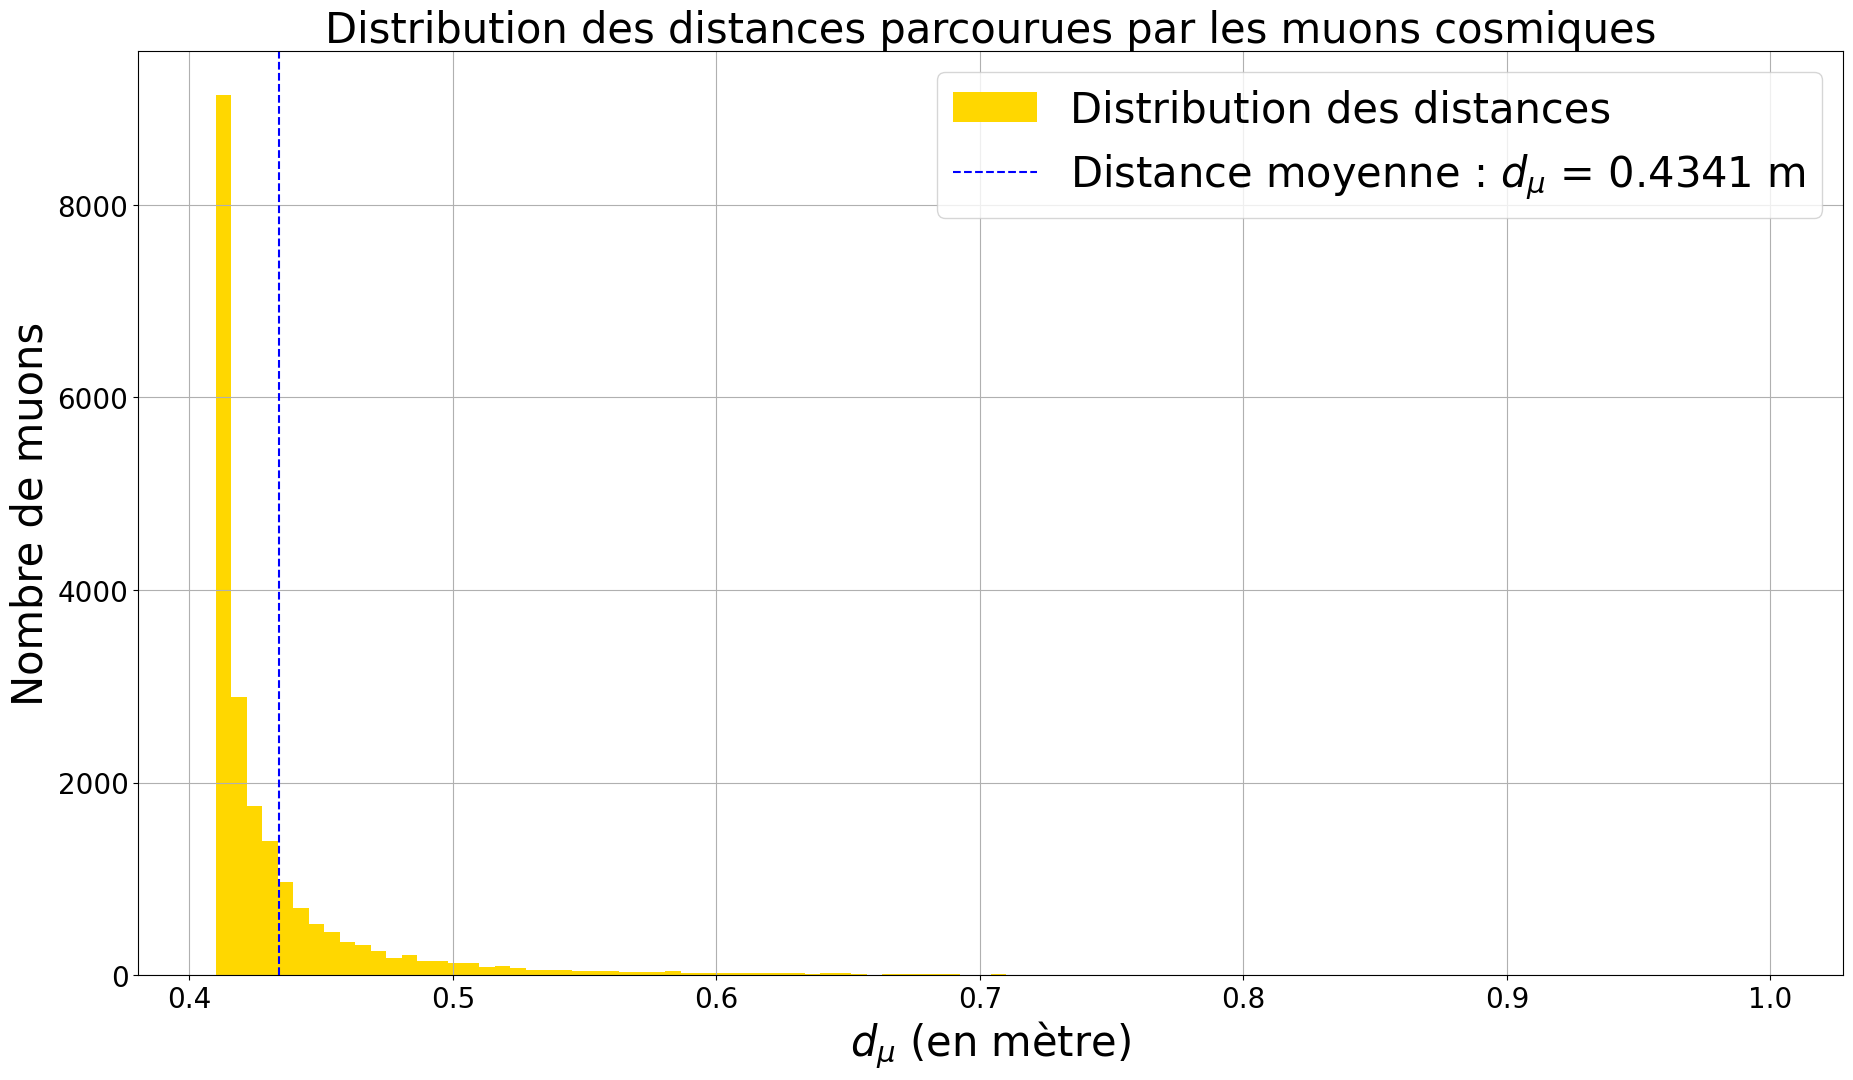

In [5]:
## Distribution pour la distance
plt.figure(figsize = (22, 12))
plt.hist(Ld, bins = 100, color = 'gold', label = 'Distribution des distances')
plt.axvline(x = np.mean(Ld), color = 'blue', label = r'Distance moyenne : $d_µ$ = {:.4g} m'.format(np.mean(Ld)), linestyle = '--')
plt.xlabel(r'$d_{\mu}$ (en mètre)', fontsize=30)
plt.ylabel('Nombre de muons', fontsize=30)
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)
plt.title(r'Distribution des distances parcourues par les muons cosmiques', fontsize = 30)
plt.legend(loc = "best", fontsize = 30)
plt.grid()
plt.show()